<a href="https://colab.research.google.com/github/slomi23/ML_fx/blob/main/feature_engineering_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone "https://github.com/slomi23/ML_fx.git"
!cd ML_fx/

Cloning into 'ML_fx'...
remote: Enumerating objects: 3243, done.
remote: Total 3243 (delta 0), reused 0 (delta 0), pack-reused 3243 (from 2)
Receiving objects: 100% (3243/3243), 39.05 MiB | 11.60 MiB/s, done.
Resolving deltas: 100% (3165/3165), done.
Updating files: 100% (3119/3119), done.


In [42]:
import pandas as pd
import numpy as np
import os
import zipfile
import io

PROCCESSED_DATA_DIR = "./ML_fx/data/processed/"
train_full=pd.read_csv(os.path.join(PROCCESSED_DATA_DIR, "train_processed.csv"))
test_full=pd.read_csv(os.path.join(PROCCESSED_DATA_DIR, "test_processed.csv"))
print(train_full.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  15

# Feature Engineering
let's create sales_lag52, sales  year ago. as well as some calendary features

In [43]:
def create_features(df1, test1):
  df = df1.copy()
  test = test1.copy()
  group_cols = ['Store', 'Dept']
  df['Date'] = pd.to_datetime(df['Date'])
  test['Date'] = pd.to_datetime(test['Date'])
  # Mark rows to split later
  df['is_train'] = True
  test['is_train'] = False
  if 'Weekly_Sales' not in test.columns:
    test['Weekly_Sales'] = np.nan

  # 3. Combine Train and Test
  all_data = pd.concat([df, test], axis=0).reset_index(drop=True)

  # 4. Sort by Store, Dept, and Date
  group_cols = ['Store', 'Dept']
  all_data = all_data.sort_values(by=[*group_cols, 'Date']).reset_index(drop=True)

  # 5. Compute Lag Feature
  # Group by Store and Dept, then shift Weekly_Sales by 52 weeks
  # Fill NaNs with 0 as requested
  all_data['sales_lag_52'] = all_data.groupby(group_cols)['Weekly_Sales'].transform(lambda x: x.shift(52))
  all_data['sales_lag_52'] = all_data['sales_lag_52'].fillna(0)
  # 6. Split Back Into Train and Test
  df = all_data[all_data['is_train']].drop('is_train', axis=1)
  test = all_data[~all_data['is_train']].drop(['is_train', 'Weekly_Sales'], axis=1)

  df['Year'] = df['Date'].dt.year
  df['Month'] = df['Date'].dt.month
  df['DayOfWeek'] = df['Date'].dt.dayofweek
  df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
  test['Year'] = test['Date'].dt.year
  test['Month'] = test['Date'].dt.month
  test['DayOfWeek'] = test['Date'].dt.dayofweek
  test['WeekOfYear'] = test['Date'].dt.isocalendar().week.astype(int)

  #sine and cosine
  df['month_sin'] = np.sin(2 * np.pi * df['Month']/12)
  df['month_cos'] = np.cos(2 * np.pi * df['Month']/12)
  df['dow_sin'] = np.sin(2 * np.pi * df['DayOfWeek']/7)
  df['dow_cos'] = np.cos(2 * np.pi * df['DayOfWeek']/7)
  df['week_sin'] = np.sin(2 * np.pi * df['WeekOfYear']/52)
  df['week_cos'] = np.cos(2 * np.pi * df['WeekOfYear']/52)
  test['month_sin'] = np.sin(2 * np.pi * test['Month']/12)
  test['month_cos'] = np.cos(2 * np.pi * test['Month']/12)
  test['dow_sin'] = np.sin(2 * np.pi * test['DayOfWeek']/7)
  test['dow_cos'] = np.cos(2 * np.pi * test['DayOfWeek']/7)
  test['week_sin'] = np.sin(2 * np.pi * test['WeekOfYear']/52)
  test['week_cos'] = np.cos(2 * np.pi * test['WeekOfYear']/52)
  #drop columns not needed
  cols_to_drop = ['Month', 'DayOfWeek', 'WeekOfYear']
  df=df.drop(columns=cols_to_drop)
  test=test.drop(columns=cols_to_drop)

  return df, test
train_full1, test_full1=create_features(train_full, test_full)

print(test_full1.head())


     Store  Dept       Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
143      1     1 2012-11-02      False        55.32       3.386    6766.44   
144      1     1 2012-11-09      False        61.24       3.314   11421.32   
145      1     1 2012-11-16      False        52.92       3.252    9696.28   
146      1     1 2012-11-23       True        56.23       3.211     883.59   
147      1     1 2012-11-30      False        52.34       3.207    2460.03   

     MarkDown2  MarkDown3  MarkDown4  ...  Type    Size  sales_lag_52  Year  \
143    5147.70      50.82    3639.90  ...     A  151315      39886.06  2012   
144    3370.89      40.28    4646.79  ...     A  151315      18689.54  2012   
145     292.10     103.78    1133.15  ...     A  151315      19050.66  2012   
146       4.17   74910.32     209.91  ...     A  151315      20911.25  2012   
147        NaN    3838.35     150.57  ...     A  151315      25293.49  2012   

     month_sin  month_cos   dow_sin   dow_cos  week_sin 

# Now let's handle NAs/Nulls and turn categorical features into numerical
target encoding for Type

In [44]:
numerical_cols = train_full1.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'sales_lag_52', 'Year', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos'],
      dtype='object')


In [45]:
def fill_missing_values(df1, test1):
  df=df1.copy()
  test=test1.copy()
  numerical_cols = df.select_dtypes(include=['number']).columns
  numerical_cols_test = list(set(numerical_cols) - {'Weekly_Sales'})
  df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
  test[numerical_cols_test] = test[numerical_cols_test].fillna(df[numerical_cols_test].median())

  categorical_cols = df.select_dtypes(include=['object', 'category']).columns
  for col in categorical_cols:
      mode_val = df[col].mode() if not df[col].mode().empty else None
      if mode_val is not None:
          df[col] = df[col].fillna(mode_val)
          test[col]=test[col].fillna(mode_val)
  return df, test
train_full2, test_full2=fill_missing_values(train_full1, test_full1)
print(train_full2.head())


   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...  Type    Size  sales_lag_52  Year  \
0    5347.45      192.0       24.6  ...     A  151315           0.0  2010   
1    5347.45      192.0       24.6  ...     A  151315           0.0  2010   
2    5347.45      192.0       24.6  ...     A  151315           0.0  2010   
3    5347.45      192.0       24.6  ...     A  151315           0.0  2010   
4    5347.45      192.0       24.6  ...     A  151315           0.0  2010   

  month_sin     month_cos   dow_sin   dow_cos  week_sin  week_

In [46]:
def cat_to_num(df1, test1):
  df=df1.copy()
  test=test1.copy()
  df['IsHoliday'] = df['IsHoliday'].astype(int)
  test['IsHoliday'] = test['IsHoliday'].astype(int)

  type_map = {'A': 20, 'B': 12, 'C': 9.5}
  if 'Type' in df.columns:
      df['Type'] = df['Type'].map(type_map).fillna(0).astype(int)
      test['Type'] = test['Type'].map(type_map).fillna(0).astype(int)

  return df, test
train_full3, test_full3=cat_to_num(train_full2, test_full2)
print(train_full3.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50          0        42.31       2.572   
1      1     1 2010-02-12      46039.49          1        38.51       2.548   
2      1     1 2010-02-19      41595.55          0        39.93       2.514   
3      1     1 2010-02-26      19403.54          0        46.63       2.561   
4      1     1 2010-03-05      21827.90          0        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...  Type    Size  sales_lag_52  Year  \
0    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
1    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
2    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
3    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
4    5347.45      192.0       24.6  ...    20  151315           0.0  2010   

   month_sin     month_cos   dow_sin   dow_cos  week_sin  week

In [48]:
train_pairs = set(zip(train_full3['Store']))
test_pairs = set(zip(test_full3['Store']))

# Check differences
missing_in_train = test_pairs - train_pairs
extra_in_test = test_pairs - train_pairs # Same as above, just for clarity
extra_in_train = train_pairs - test_pairs

print(f"Stores in Train unique Store pairs: {len(train_pairs)}")
print(f"Stores in Test unique Store pairs: {len(test_pairs)}")
print(f"Stores in Test but NOT in Train: {len(missing_in_train)}")
print(f"Stores in  Train but NOT in Test: {len(extra_in_train)}")

if len(missing_in_train) > 0:
    print("\nExample of Store in Test but not in Train:")
    print(list(missing_in_train))

Stores in Train unique Store pairs: 45
Stores in Test unique Store pairs: 45
Stores in Test but NOT in Train: 0
Stores in  Train but NOT in Test: 0


In [49]:
train_pairs = set(zip(train_full3['Store'], train_full3['Dept']))
test_pairs = set(zip(test_full3['Store'], test_full3['Dept']))

# Check differences
missing_in_train = test_pairs - train_pairs
extra_in_test = test_pairs - train_pairs # Same as above, just for clarity
extra_in_train = train_pairs - test_pairs

print(f"Train unique Store/Dept pairs: {len(train_pairs)}")
print(f"Test unique Store/Dept pairs: {len(test_pairs)}")
print(f"Pairs in Test but NOT in Train: {len(missing_in_train)}")
print(f"Pairs in Train but NOT in Test: {len(extra_in_train)}")

if len(missing_in_train) > 0:
    print("\nExample of Store/Dept in Test but not in Train:")
    print(list(missing_in_train))

Train unique Store/Dept pairs: 3331
Test unique Store/Dept pairs: 3169
Pairs in Test but NOT in Train: 11
Pairs in Train but NOT in Test: 173

Example of Store/Dept in Test but not in Train:
[(18, 43), (24, 43), (36, 30), (37, 29), (25, 99), (9, 99), (34, 39), (45, 39), (42, 30), (10, 99), (5, 99)]


In [76]:
problematic_pairs = [(18, 43), (24, 43), (36, 30), (37, 29), (25, 99), (9, 99), (34, 39), (45, 39), (42, 30), (10, 99), (5, 99)]
test_set=test_full3
print("Checking sales_lag_52 for problematic pairs in Test:")
for store, dept in problematic_pairs:
    mask = (test_set['Store'] == store) & (test_set['Dept'] == dept)
    if mask.any():
        df_pair = test_set[mask]
        # Count how many rows have valid lags vs NaN
        valid_count = df_pair['sales_lag_52'].notna().sum()
        nan_count = df_pair['sales_lag_52'].isna().sum()

        print(f"Store {store}, Dept {dept}:")
        print(f"  Total rows in test: {len(df_pair)}")
        print(f"  Rows with valid sales_lag_52: {valid_count}")
        print(f"  Rows with NaN sales_lag_52: {nan_count}")

        # Show first few rows
        print(df_pair[['Date', 'sales_lag_52']].head())
        print("-" * 20)
    else:
        print(f"Store {store}, Dept {dept}: Not found in test set.")

Checking sales_lag_52 for problematic pairs in Test:
Store 18, Dept 43:
  Total rows in test: 1
  Rows with valid sales_lag_52: 1
  Rows with NaN sales_lag_52: 0
             Date  sales_lag_52
219997 2013-04-26           0.0
--------------------
Store 24, Dept 43:
  Total rows in test: 1
  Rows with valid sales_lag_52: 1
  Rows with NaN sales_lag_52: 0
             Date  sales_lag_52
295931 2013-06-21           0.0
--------------------
Store 36, Dept 30:
  Total rows in test: 2
  Rows with valid sales_lag_52: 2
  Rows with NaN sales_lag_52: 0
             Date  sales_lag_52
436433 2012-11-02           0.0
436434 2013-03-15           0.0
--------------------
Store 37, Dept 29:
  Total rows in test: 12
  Rows with valid sales_lag_52: 12
  Rows with NaN sales_lag_52: 0
             Date  sales_lag_52
444807 2012-11-30           0.0
444808 2012-12-07           0.0
444809 2012-12-14           0.0
444810 2012-12-21           0.0
444811 2013-01-04           0.0
--------------------
Store 25,

In [77]:
import pandas as pd

# 1. Calculate average sales_lag_52 for each Store/Dept where lag > 0
# We use the train data (train_full1) because test_set lags are mostly 0/NaN for new stores
valid_test = test_set[test_set['sales_lag_52'] > 0]

avg_lag_df = valid_test.groupby(['Store', 'Type'])['sales_lag_52'].mean().reset_index()
avg_lag_df.rename(columns={'sales_lag_52': 'avg_lag'}, inplace=True)

# Merge into test_set
test_set = test_set.merge(avg_lag_df, on=['Store', 'Type'], how='left')


In [78]:
mask = (test_set['sales_lag_52'] == 0) | test_set['sales_lag_52'].isna()
test_set.loc[mask, 'sales_lag_52'] = test_set.loc[mask, 'avg_lag']

In [79]:
print(test_set.head())

   Store  Dept       Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0      1     1 2012-11-02          0        55.32       3.386    6766.44   
1      1     1 2012-11-09          0        61.24       3.314   11421.32   
2      1     1 2012-11-16          0        52.92       3.252    9696.28   
3      1     1 2012-11-23          1        56.23       3.211     883.59   
4      1     1 2012-11-30          0        52.34       3.207    2460.03   

   MarkDown2  MarkDown3  MarkDown4  ...    Size  sales_lag_52  Year  \
0    5147.70      50.82    3639.90  ...  151315      39886.06  2012   
1    3370.89      40.28    4646.79  ...  151315      18689.54  2012   
2     292.10     103.78    1133.15  ...  151315      19050.66  2012   
3       4.17   74910.32     209.91  ...  151315      20911.25  2012   
4     192.00    3838.35     150.57  ...  151315      25293.49  2012   

   month_sin  month_cos   dow_sin   dow_cos  week_sin  week_cos       avg_lag  
0       -0.5   0.866025 -0.433884 -0

In [80]:
print(len(test_set[test_set['sales_lag_52'].isna()]))
print(len(test_set[test_set['avg_lag'].isna()]))

0
0


In [82]:
test_set.drop(columns=['avg_lag'], inplace=True)
print(test_set.head())


   Store  Dept       Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0      1     1 2012-11-02          0        55.32       3.386    6766.44   
1      1     1 2012-11-09          0        61.24       3.314   11421.32   
2      1     1 2012-11-16          0        52.92       3.252    9696.28   
3      1     1 2012-11-23          1        56.23       3.211     883.59   
4      1     1 2012-11-30          0        52.34       3.207    2460.03   

   MarkDown2  MarkDown3  MarkDown4  ...  Type    Size  sales_lag_52  Year  \
0    5147.70      50.82    3639.90  ...    20  151315      39886.06  2012   
1    3370.89      40.28    4646.79  ...    20  151315      18689.54  2012   
2     292.10     103.78    1133.15  ...    20  151315      19050.66  2012   
3       4.17   74910.32     209.91  ...    20  151315      20911.25  2012   
4     192.00    3838.35     150.57  ...    20  151315      25293.49  2012   

   month_sin  month_cos   dow_sin   dow_cos  week_sin  week_cos  
0       -0.5  

In [83]:
problematic_pairs = [(18, 43), (24, 43), (36, 30), (37, 29), (25, 99), (9, 99), (34, 39), (45, 39), (42, 30), (10, 99), (5, 99)]
print("Checking sales_lag_52 for problematic pairs in Test:")
for store, dept in problematic_pairs:
    mask = (test_set['Store'] == store) & (test_set['Dept'] == dept)
    if mask.any():
        df_pair = test_set[mask]
        # Count how many rows have valid lags vs NaN
        valid_count = df_pair['sales_lag_52'].notna().sum()
        nan_count = df_pair['sales_lag_52'].isna().sum()

        print(f"Store {store}, Dept {dept}:")
        print(f"  Total rows in test: {len(df_pair)}")
        print(f"  Rows with valid sales_lag_52: {valid_count}")
        print(f"  Rows with NaN sales_lag_52: {nan_count}")

        # Show first few rows
        print(df_pair[['Date', 'sales_lag_52']].head())
        print("-" * 20)
    else:
        print(f"Store {store}, Dept {dept}: Not found in test set.")

Checking sales_lag_52 for problematic pairs in Test:
Store 18, Dept 43:
  Total rows in test: 1
  Rows with valid sales_lag_52: 1
  Rows with NaN sales_lag_52: 0
            Date  sales_lag_52
47108 2013-04-26  16116.077371
--------------------
Store 24, Dept 43:
  Total rows in test: 1
  Rows with valid sales_lag_52: 1
  Rows with NaN sales_lag_52: 0
            Date  sales_lag_52
63358 2013-06-21  19342.928421
--------------------
Store 36, Dept 30:
  Total rows in test: 2
  Rows with valid sales_lag_52: 2
  Rows with NaN sales_lag_52: 0
            Date  sales_lag_52
93407 2012-11-02   7768.865041
93408 2013-03-15   7768.865041
--------------------
Store 37, Dept 29:
  Total rows in test: 12
  Rows with valid sales_lag_52: 12
  Rows with NaN sales_lag_52: 0
            Date  sales_lag_52
95198 2012-11-30  10726.404746
95199 2012-12-07  10726.404746
95200 2012-12-14  10726.404746
95201 2012-12-21  10726.404746
95202 2013-01-04  10726.404746
--------------------
Store 25, Dept 99:
  T

In [84]:
print(len(test_set[test_set['sales_lag_52']==0]))


0


# Feature importances

In [85]:
print(len(train_full3))
print(train_full3.head())

421570
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50          0        42.31       2.572   
1      1     1 2010-02-12      46039.49          1        38.51       2.548   
2      1     1 2010-02-19      41595.55          0        39.93       2.514   
3      1     1 2010-02-26      19403.54          0        46.63       2.561   
4      1     1 2010-03-05      21827.90          0        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...  Type    Size  sales_lag_52  Year  \
0    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
1    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
2    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
3    5347.45      192.0       24.6  ...    20  151315           0.0  2010   
4    5347.45      192.0       24.6  ...    20  151315           0.0  2010   

   month_sin     month_cos   dow_sin   dow_cos  week_si

/tmp/ipykernel_2833/20012643.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=abs_corr.values, y=abs_corr.index, palette='viridis')


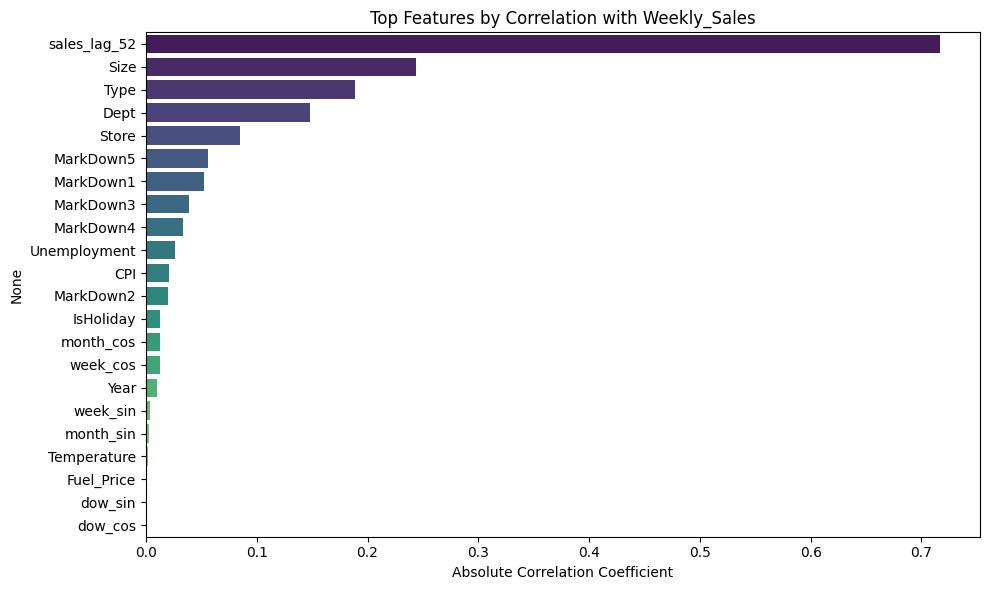

sales_lag_52    0.716951
Size            0.243828
Type            0.188469
Dept            0.148032
Store           0.085195
MarkDown5       0.055702
MarkDown1       0.052739
MarkDown3       0.038524
MarkDown4       0.033820
Unemployment    0.025864
CPI             0.020921
MarkDown2       0.020342
IsHoliday       0.012774
month_cos       0.012663
week_cos        0.012459
Name: Weekly_Sales, dtype: float64


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train_set=train_full3
# Select numeric columns only (exclude Store, Dept, Date, IsHoliday if you want pure continuous)
numeric_cols = train_set.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation with Weekly_Sales
correlations = train_set[numeric_cols].corr()['Weekly_Sales'].drop('Weekly_Sales')

# Sort by absolute value
abs_corr = correlations.abs().sort_values(ascending=False)

# Plot Top 15
plt.figure(figsize=(10, 6))
sns.barplot(x=abs_corr.values, y=abs_corr.index, palette='viridis')
plt.title('Top Features by Correlation with Weekly_Sales')
plt.xlabel('Absolute Correlation Coefficient')
plt.tight_layout()
plt.show()

print(abs_corr.head(15))


In [87]:
print(test_set.head())

   Store  Dept       Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0      1     1 2012-11-02          0        55.32       3.386    6766.44   
1      1     1 2012-11-09          0        61.24       3.314   11421.32   
2      1     1 2012-11-16          0        52.92       3.252    9696.28   
3      1     1 2012-11-23          1        56.23       3.211     883.59   
4      1     1 2012-11-30          0        52.34       3.207    2460.03   

   MarkDown2  MarkDown3  MarkDown4  ...  Type    Size  sales_lag_52  Year  \
0    5147.70      50.82    3639.90  ...    20  151315      39886.06  2012   
1    3370.89      40.28    4646.79  ...    20  151315      18689.54  2012   
2     292.10     103.78    1133.15  ...    20  151315      19050.66  2012   
3       4.17   74910.32     209.91  ...    20  151315      20911.25  2012   
4     192.00    3838.35     150.57  ...    20  151315      25293.49  2012   

   month_sin  month_cos   dow_sin   dow_cos  week_sin  week_cos  
0       -0.5  

In [88]:
import os

# 1. Ensure the directory exists
output_dir = './ML_fx/data/processed'
os.makedirs(output_dir, exist_ok=True)

# 2. Save the DataFrame to CSV
train_full3.to_csv(os.path.join(output_dir, 'train_prepared.csv'), index=False)
test_set.to_csv(os.path.join(output_dir, 'test_prepared.csv'), index=False)

print("Files saved successfully!")

Files saved successfully!
